# 1.1 有理数的引入

这一节参考六年级上册教材第 1 章第 1 节：从温度、海拔、收支这些真实情境出发，认识正数、负数、数轴和相反数。

我们不急着背定义，先看一个更重要的问题：**为什么小学学过的数不够用了？**

## 学习目标

学完本节，你应该能做到：

- 用正数和负数表示具有相反意义的量。
- 判断一个数是正数、负数还是 0。
- 说出整数、分数和有理数之间的关系。
- 在数轴上表示有理数，并读出点表示的数。
- 理解相反数：符号相反、到 0 的距离相等。

**思维视角：分类讨论 + 数形结合。**

分类讨论帮助我们把数分成正数、负数和 0；数形结合帮助我们把抽象的数放到一条线上观察。

## 问题情境：同一个 0，两边意义不同

教材用温度引入：

- 零上 5 摄氏度，记作 $+5^\circ C$，通常也可以写作 $5^\circ C$。
- 零下 2 摄氏度，记作 $-2^\circ C$。

这里的 0 不是“没有温度”，而是一个**分界点**。比 0 高，用正数；比 0 低，用负数。

同样，海平面也可以当分界点：珠穆朗玛峰高于海平面，记作正数；吐鲁番盆地的艾丁湖低于海平面，记作负数。

银行账本也一样：收入可以记作正数，支出可以记作负数。

## 本节要用到的 Python 工具

下面先导入本节需要的几个工具。第一次看到 `matplotlib` 时，不需要记住它的全部用法；先知道它可以用来画图，帮助我们把数轴画出来。更具体的说明见本节最后的“附录：本节遇到的重要库”，也可以打开 [Matplotlib 库小节](../附录/matplotlib库.ipynb)。

In [36]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

def draw_number_line(values=None, labels=None, xmin=-6, xmax=6, title="number line"):
    """画一条数轴，并在数轴上标出指定的数。

    参数说明：
    values: 要标在数轴上的数，可以是整数、小数或 Fraction 分数。
    labels: 每个点旁边显示的文字；如果不传，就直接显示 values 中的数。
    xmin: 数轴左端显示到哪里。
    xmax: 数轴右端显示到哪里。
    title: 图的标题，用来说明这条数轴表达的情境。
    """
    values = values or []
    labels = labels or [str(v) for v in values]

    fig, ax = plt.subplots(figsize=(9, 1.8))
    axis_right = xmax + 0.35
    ax.annotate("", xy=(axis_right, 0), xytext=(xmin, 0), arrowprops=dict(arrowstyle="->", color="black"))

    ticks = np.arange(np.ceil(xmin), np.floor(xmax) + 1)
    for t in ticks:
        ax.plot([t, t], [-0.06, 0.06], color="black", linewidth=1)
        ax.text(t, -0.18, str(int(t)), ha="center", va="top", fontsize=10)

    for x, label in zip(values, labels):
        ax.scatter([float(x)], [0], s=70, color="#d62728", zorder=3)
        ax.text(float(x), 0.24, label, ha="center", va="bottom", fontsize=11, color="#d62728")

    ax.set_xlim(xmin - 0.3, axis_right + 0.05)
    ax.set_ylim(-0.55, 0.65)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

## 正数、负数和 0

像 $+5$、$+8848.86$、$+\frac{3}{4}$ 这样，前面有“+”号的数叫做**正数**。正号通常可以省略，所以 $+5$ 可以写成 $5$。

像 $-2$、$-154.31$、$-\frac{9}{7}$ 这样，前面有“-”号的数叫做**负数**。

**0 既不是正数，也不是负数。**

这句话很关键。0 是分界点，不属于任何一边。

In [37]:
examples = [
    Fraction(-12, 1), Fraction(71, 1), Fraction(-28, 10), Fraction(0, 1),
    Fraction(-3, 10), Fraction(11, 2), Fraction(23, 100),
    Fraction(-3, 4), Fraction(12, 7), Fraction(-9, 5),
]

def sign_type(x):
    if x > 0:
        return "正数"
    if x < 0:
        return "负数"
    return "0：既不是正数，也不是负数"

for x in examples:
    print(f"{str(x):>6} -> {sign_type(x)}")

   -12 -> 负数
    71 -> 正数
 -14/5 -> 负数
     0 -> 0：既不是正数，也不是负数
 -3/10 -> 负数
  11/2 -> 正数
23/100 -> 正数
  -3/4 -> 负数
  12/7 -> 正数
  -9/5 -> 负数


上面的代码在做一件很简单但很重要的事：

1. 先和 0 比较。
2. 大于 0，归入正数。
3. 小于 0，归入负数。
4. 等于 0，单独留下。

这就是分类讨论。分类时，边界点 0 最容易被误放进正数或负数。

## 有理数：能写成分数的数

教材把正整数、负整数和 0 统称为**整数**。

整数其实也能写成分母为 1 的分数：

$$3=\frac{3}{1},\qquad -5=\frac{-5}{1},\qquad 0=\frac{0}{1}$$

能够写成 $\frac{b}{a}$ 的数叫做**有理数**，其中 $a$、$b$ 是整数，并且 $a\ne 0$。

所以：自然数是整数的一部分，整数是有理数的一部分。小学认识的正分数，现在也扩展到负分数。

In [38]:
numbers = [0, 1, 2, -1, -2, Fraction(1, 2), Fraction(-2, 3), Fraction(12, 7)]

print("把这些有理数写成分数形式：")
for x in numbers:
    f = Fraction(x)
    print(f"{str(x):>5} = {f.numerator}/{f.denominator}")

把这些有理数写成分数形式：
    0 = 0/1
    1 = 1/1
    2 = 2/1
   -1 = -1/1
   -2 = -2/1
  1/2 = 1/2
 -2/3 = -2/3
 12/7 = 12/7


## 数轴：把数放到一条线上

如果只看符号，我们知道正数在 0 的一边，负数在另一边。

但数轴让我们看得更清楚：

- 原点表示 0。
- 规定一个方向为正方向，通常向右为正。
- 规定一个单位长度。
- 正数在原点右边，负数在原点左边。

数轴把“数的大小”和“点的位置”联系起来，这就是数形结合。

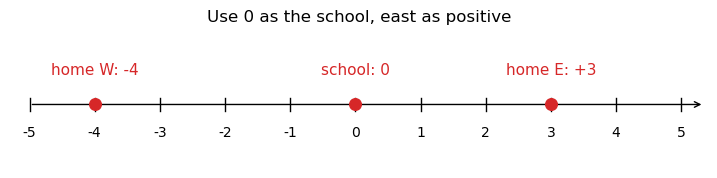

In [42]:
draw_number_line(
    values=[-4, 0, 3],
    labels=["home W: -4", "school: 0", "home E: +3"],
    xmin=-5,
    xmax=5,
    title="Use 0 as the school, east as positive"
)

在这张图里，学校是基准点 0。

- 小海家在学校正东方 3 km，所以记作 $+3$。
- 小华家在学校正西方 4 km，所以记作 $-4$。

注意：正负号不是装饰，它告诉我们这个量相对于基准点的方向。

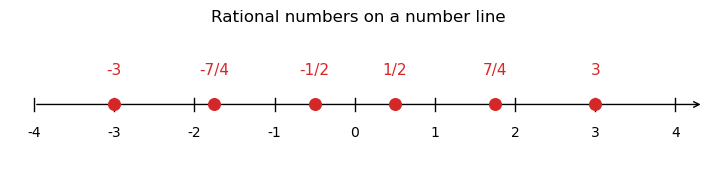

In [11]:
values = [3, -3, Fraction(1, 2), Fraction(-1, 2), Fraction(7, 4), Fraction(-7, 4)]
labels = ["3", "-3", "1/2", "-1/2", "7/4", "-7/4"]
draw_number_line(values=values, labels=labels, xmin=-4, xmax=4, title="Rational numbers on a number line")

教材中的一句话可以这样理解：**每一个有理数，都可以用数轴上唯一的一个点表示。**

例如 $\frac{7}{4}=1.75$，它在 1 和 2 之间；$-\frac{7}{4}=-1.75$，它在 -2 和 -1 之间。

## 相反数：离 0 一样远，方向相反

在数轴上，3 和 -3 有一个特别的关系：

- 一个在 0 的右边，一个在 0 的左边。
- 它们到 0 的距离都是 3。

像这样，只有符号不同的两个数，互为**相反数**。

一般地，数 $a$ 的相反数是 $-a$。特别地，0 的相反数是 0。

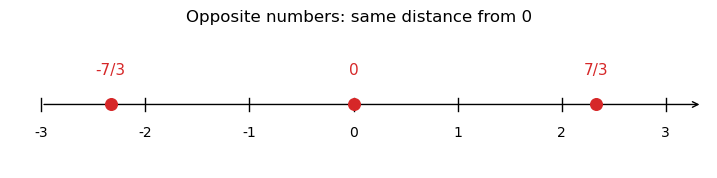

a = 7/3, -a = -7/3
distance from 0: |a| = 7/3, |-a| = 7/3


In [43]:
a = Fraction(7, 3)
opposite = -a

draw_number_line(
    values=[opposite, 0, a],
    labels=[f"-{a}", "0", f"{a}"],
    xmin=-3,
    xmax=3,
    title="Opposite numbers: same distance from 0"
)

print(f"a = {a}, -a = {opposite}")
print(f"distance from 0: |a| = {abs(a)}, |-a| = {abs(opposite)}")

## 绝对值

在数轴上，$3$ 和 $-3$ 到 0 的距离都是 3。现在我们给这个"距离"起一个名字，叫**绝对值**。

一个数 $a$ 的绝对值，记作 $|a|$，就是 $a$ 在数轴上到 0 的距离。

- 如果 $a \ge 0$，那么 $|a| = a$（正数或 0 的绝对值就是它本身）。
- 如果 $a < 0$，那么 $|a| = -a$（负数的绝对值是它的相反数，是一个正数）。

特别地，$|0| = 0$。

**注意**：绝对值总是非负的，没有负数的绝对值。

In [45]:
def abs_value(x):
    """返回 x 的绝对值。"""
    return x if x >= 0 else -x

# 演示绝对值
examples = [-5, -1.5, 0, Fraction(3, 4), -Fraction(7, 2), 2]
print("绝对值的例子：")
print("-" * 40)
for x in examples:
    print(f"|{str(x):>6}| = {abs_value(x)}")


绝对值的例子：
----------------------------------------
|    -5| = 5
|  -1.5| = 1.5
|     0| = 0
|   3/4| = 3/4
|  -7/2| = 7/2
|     2| = 2


### 绝对值与相反数

如果两个数的绝对值相等，它们一定互为相反数吗？来看看：

In [46]:
# 当两个数的绝对值相等时
test_pairs = [
    (2, -2),
    (Fraction(1, 2), -Fraction(1, 2)),
    (0, 0),
]

print("两个数的绝对值相等时，它们互为相反数吗？")
print("-" * 50)
for a, b in test_pairs:
    abs_a = abs_value(a)
    abs_b = abs_value(b)
    opposite = -a
    print(f"|{str(a):>6}| = {abs_a},  |{str(b):>6}| = {abs_b}")
    print(f"  -> |{a}| = |{b}|? {abs_a == abs_b}")
    print(f"  -> {b} = -{a}? {b == opposite}")
    print()


两个数的绝对值相等时，它们互为相反数吗？
--------------------------------------------------
|     2| = 2,  |    -2| = 2
  -> |2| = |-2|? True
  -> -2 = -2? True

|   1/2| = 1/2,  |  -1/2| = 1/2
  -> |1/2| = |-1/2|? True
  -> -1/2 = -1/2? True

|     0| = 0,  |     0| = 0
  -> |0| = |0|? True
  -> 0 = -0? True



## 有理数的大小比较

有理数有正数、零和负数三种。比较任意两个有理数的大小时，我们要分情况讨论：

1. **正数 > 0**
2. **0 > 负数**
3. **两个正数的比较**：绝对值大的数就大。
4. **两个负数的比较**：这是新的情况。看数轴上的位置：$-3$ 在 $-1$ 的左边，所以 $-3 < -1$。**绝对值大的负数反而更小。**
5. **正数 > 0 > 负数**

关键是第 4 种情况：**负数比较是反过来的**。这也是为什么绝对值这个工具很重要。

In [29]:
def compare_positve(x, y):
    """比较两个正数的大小。

    返回：
    -1: x < y
     0: x = y
     1: x > y
    """
    assert x >= 0 and y >= 0, "x 和 y 必须是非负数"
    if x < y:
        return -1
    if x > y:
        return 1
    return 0

def compare(x, y):
    """比较两个有理数的大小。

    返回：
    -1: x < y
     0: x = y
     1: x > y
    
    核心思想：分类讨论
    - 一正一负：正数大
    - 两个正数：绝对值大的数大
    - 两个负数：绝对值大的数反而小
    """
    if x > 0 and y < 0:
        # 正数 > 负数
        return 1
    elif x < 0 and y > 0:
        # 负数 < 正数
        return -1
    elif x >= 0 and y >= 0:
        # 两个非负数，直接比较
        return compare_positve(x, y)
    else:
        # 两个都是负数，比较绝对值，结果反向
        abs_result = compare_positve(abs_value(x), abs_value(y))
        return -abs_result


In [47]:
# 演示有理数的比较
test_cases = [
    (3, -2, "正数 > 负数"),
    (-2, 3, "负数 < 正数"),
    (0, 5, "0 < 正数"),
    (-3, 0, "负数 < 0"),
    (2, 5, "两个正数：2 < 5"),
    (-3, -1, "两个负数：-3 < -1（绝对值大反而小）"),
    (Fraction(1, 2), Fraction(3, 4), "正分数：1/2 < 3/4"),
    (-Fraction(3, 4), -Fraction(1, 2), "负分数：-3/4 < -1/2"),
    (2, 2, "相等：2 = 2"),
]

print("比较有理数大小的例子：")
print("-" * 60)
result_map = {-1: "<", 0: "=", 1: ">"}

for x, y, desc in test_cases:
    result = compare(x, y)
    symbol = result_map[result]
    print(f"{str(x):>6} {symbol} {str(y):<6}  ({desc})")


比较有理数大小的例子：
------------------------------------------------------------
     3 > -2      (正数 > 负数)
    -2 < 3       (负数 < 正数)
     0 < 5       (0 < 正数)
    -3 < 0       (负数 < 0)
     2 < 5       (两个正数：2 < 5)
    -3 < -1      (两个负数：-3 < -1（绝对值大反而小）)
   1/2 < 3/4     (正分数：1/2 < 3/4)
  -3/4 < -1/2    (负分数：-3/4 < -1/2)
     2 = 2       (相等：2 = 2)


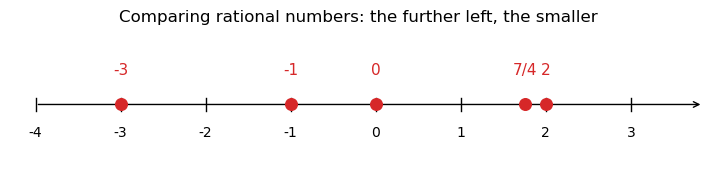

In [31]:

# 在数轴上观察比较结果
compare_values = [-3, -1, 0, 2, Fraction(7, 4)]
compare_labels = ["-3", "-1", "0", "2", "7/4"]
draw_number_line(
    compare_values, 
    compare_labels, 
    xmin=-4, 
    xmax=3.5, 
    title="Comparing rational numbers: the further left, the smaller"
)


## 练习

1. 如果规定向东为正，那么 $-50$ m 表示什么？如果规定向南为正，$-50$ m 又表示什么？
2. 如果 $-1000$ 元表示支出 1000 元，那么 $+1200$ 元表示什么？
3. 在 $8, -3, 3\frac{1}{4}, -\frac{5}{6}, 68, 0, 0.32, -\frac{7}{5}, -3.1$ 中，哪些是有理数？哪些是整数？哪些是正数？哪些是负数？
4. 如果一个数不是正数，那么它一定是负数吗？为什么？
5. 在数轴上画出 $-2, 1, -\frac{1}{2}, 2.5, 0$。

<details>
<summary>参考思路</summary>

1. 关键看“正方向”怎么规定。向东为正时，$-50$ m 表示向西 50 m；向南为正时，$-50$ m 表示向北 50 m。
2. $+1200$ 元表示收入 1200 元。
3. 这些数都是有理数；整数有 $8, -3, 68, 0$；正数有 $8, 3\frac{1}{4}, 68, 0.32$；负数有 $-3, -\frac{5}{6}, -\frac{7}{5}, -3.1$。0 既不是正数，也不是负数。
4. 不一定。0 不是正数，也不是负数。
5. 先画原点 0 和单位长度，再按大小放点：$-2 < -\frac{1}{2} < 0 < 1 < 2.5$。

</details>

## 编程题

**第 1 题**：在数轴上画出 $-2,\ 1,\ -\dfrac{1}{2},\ 2.5,\ 0$，并从左到右排列这五个数。

提示：先把这五个数放进一个列表，再思考它们在数轴上的位置。

In [ ]:
# 你的代码开始
practice_values = []
practice_labels = []

# 在这里调用 draw_number_line 画图
# 提示：draw_number_line(practice_values, practice_labels, xmin=-3, xmax=3, title="Practice")

# 按从小到大排列并打印
# 提示：可以用 sorted(practice_values)
# 你的代码结束

  my_abs(    -5) = None
  my_abs(  -3/4) = None
  my_abs(     0) = None
  my_abs(   7/2) = None
  my_abs(     3) = None


**第 2 题**：用分类讨论实现绝对值函数，不能调用 Python 内置的 `abs()`。

提示：$a$ 和 0 的大小关系只有两种——是不是可以各写一个分支？

In [ ]:
def my_abs(x):
    """用分类讨论实现绝对值，不调用内置 abs()。"""
    # 你的代码开始
    pass
    # 你的代码结束

# 验证
tests = [-5, -Fraction(3, 4), 0, Fraction(7, 2), 3]
for t in tests:
    print(f"  my_abs({str(t):>6}) = {my_abs(t)}")

验证 my_compare：
       3 > -2
      -2 < 3
       0 < 5
      -3 < 0
       2 < 5
      -3 < -1
     1/2 < 3/4
    -3/4 < -1/2
       2 = 2


**第 3 题**：用分类讨论实现 `my_compare(x, y)`，比较两个有理数的大小，返回 `-1`、`0` 或 `1`。

本节的 `compare()` 函数把两个有理数分成了四种情况，你能找出这四种吗？

提示：先想"一正一负"怎么判断，再想"同号"怎么判断。

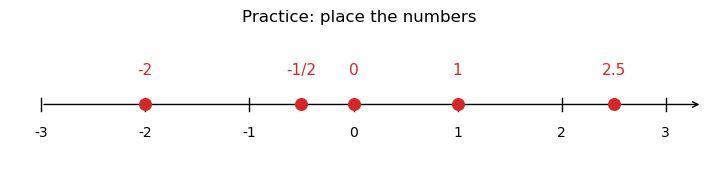

In [ ]:
def my_compare(x, y):
    """用分类讨论比较两个有理数的大小。

    返回：
    -1: x < y
     0: x = y
     1: x > y

    四种情况：
    1. ...
    2. ...
    3. ...
    4. ...
    """
    # 你的代码开始
    pass
    # 你的代码结束

# 验证
result_map = {-1: "<", 0: "=", 1: ">"}
test_cases = [
    (3, -2), (-2, 3), (0, 5), (-3, 0),
    (2, 5), (-3, -1),
    (Fraction(1, 2), Fraction(3, 4)),
    (-Fraction(3, 4), -Fraction(1, 2)),
    (2, 2),
]
for x, y in test_cases:
    r = my_compare(x, y)
    if r in result_map:
        print(f"  {str(x):>6} {result_map[r]} {y}")
    else:
        print("  请先完成 my_compare 再验证")
        break

## 编程题解答

<details>
<summary>第 1 题：参考答案</summary>

从左到右（从小到大）排列：$-2 < -\dfrac{1}{2} < 0 < 1 < 2.5$

```python
practice_values = [-2, 1, Fraction(-1, 2), Fraction(5, 2), 0]
practice_labels = ["-2", "1", "-1/2", "2.5", "0"]

draw_number_line(practice_values, practice_labels, xmin=-3, xmax=3, title="Practice: place the numbers")
print("从小到大：", sorted(practice_values))
```

</details>

<details>
<summary>第 2 题：参考答案</summary>

```python
def my_abs(x):
    if x >= 0:
        return x
    else:
        return -x
```

分析：$a$ 和 0 只有两种大小关系。$a \geq 0$ 时，绝对值就是它本身；$a < 0$ 时，绝对值是它的相反数 $-a$（一个正数）。

</details>

<details>
<summary>第 3 题：参考答案</summary>

四种情况：
1. **$x > 0$，$y < 0$**：正数比负数大，返回 1。
2. **$x < 0$，$y > 0$**：负数比正数小，返回 -1。
3. **$x \geq 0$，$y \geq 0$**：两个非负数，直接比大小。
4. **$x < 0$，$y < 0$**：两个负数，比绝对值，绝对值大的反而小，结果反向。

```python
def my_compare(x, y):
    if x > 0 and y < 0:
        return 1
    elif x < 0 and y > 0:
        return -1
    elif x >= 0 and y >= 0:
        if x < y:
            return -1
        elif x > y:
            return 1
        else:
            return 0
    else:  # 两个都是负数
        ax, ay = my_abs(x), my_abs(y)
        if ax < ay:
            return 1
        elif ax > ay:
            return -1
        else:
            return 0
```

</details>

## 小结

这一节我们把数的世界向两边扩展了：

- 有相反意义的量，可以用正数和负数表示。
- 0 是分界点，既不是正数，也不是负数。
- 能写成 $\frac{b}{a}$，其中 $a$、$b$ 是整数且 $a\ne0$ 的数，叫有理数。
- 数轴由原点、正方向和单位长度组成。
- 相反数在数轴上位于 0 的两侧，并且到 0 的距离相等。

下一节学习有理数的加法与减法时，数轴会继续帮我们理解"方向"和"距离"。

## 附录：本节遇到的重要库

本节只需要了解这些库中和“有理数的引入”直接相关的一小部分。更详细的说明放在附录文件夹中：

- [fractions 库：用 Fraction 准确表示分数](../附录/fractions库.ipynb)
- [NumPy 库：生成数轴刻度](../附录/numpy库.ipynb)
- [Matplotlib 库：画出数轴](../附录/matplotlib库.ipynb)